In [1]:
import warnings
warnings.simplefilter("ignore")
import numpy as np
import pandas as pd 
from lightkurve import LightCurve
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

for att in ['axes.labelsize', 'axes.titlesize', 'legend.fontsize',
            'legend.fontsize', 'xtick.labelsize', 'ytick.labelsize']:
    plt.rcParams[att] = 15

search_result = search_lightcurve("AU Mic") 
#print(search_result)
lc2min = search_result[4].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

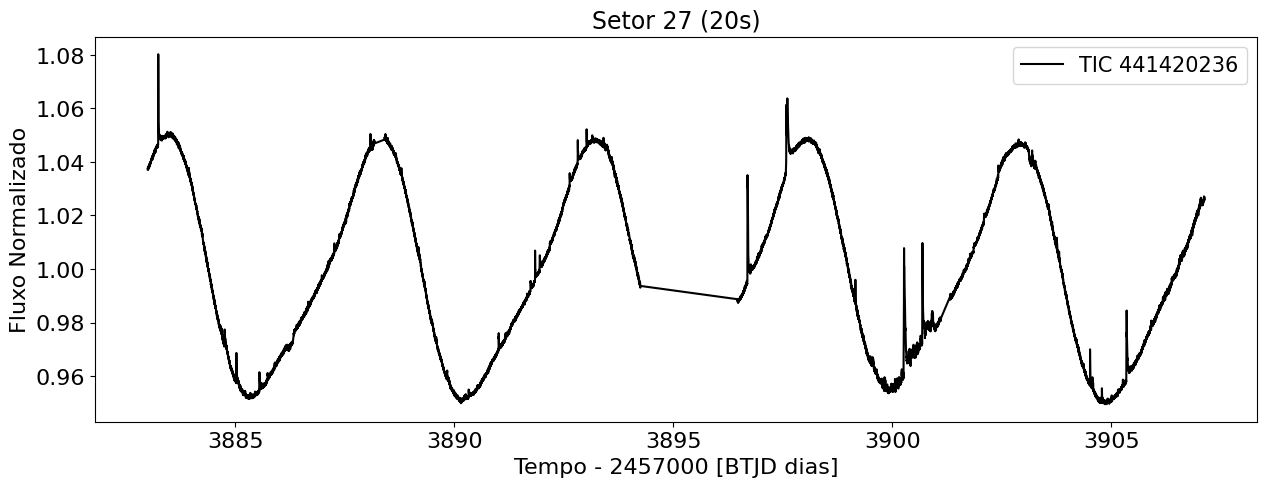

<IPython.core.display.Javascript object>

In [10]:

plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 27 (20s)').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()

from IPython.display import Javascript, display

display(Javascript("alert('teste');"))

In [11]:
# Célula 3: Processamento do Detrending com Máscara
# Definindo os vetores para mascarar flares (conforme New_Setor1)
vetores = [
    [3883.243, 3883.3707], [3884.7508, 3884.8310], [3886.1570, 3886.4341],
    [1328.4130, 1328.690], [1328.7326, 1328.7474], [1329.3756, 1329.4123],
    [1330.1210, 1330.1377], [1330.4496, 1330.5464], [1331.8210, 1331.8574],
    [1333.8797, 1333.9809], [1334.1134, 1334.1507], [1335.1052, 1335.2524],
    [1335.3517, 1335.4232], [1335.7022, 1335.7252], [1336.2287, 1336.2454],
    [1336.9519, 1336.9890], [1337.0179, 1337.0633], [1338.2201, 1338.2396],
    [1338.4973, 1338.5127], [1343.5045, 1343.5218], [1345.3914, 1345.4122],
    [1345.3918, 1345.4119], [1345.5044, 1345.5562], [1346.1841, 1346.2377],
    [1346.5162, 1346.5464], [1350.0068, 1350.0502], [1350.1441, 1350.3345],
    [1350.2795, 1350.3247], [1330.3039, 1330.4724], [1347.3173, 1347.3250],
    [1342.2240, 1342.2398], [1352.3514, 1352.3619], [1349.4516, 1349.4714],
    [1349.8142, 1349.8432], [1345.3926, 1345.4123], [1350.2720, 1350.3608],
    [1350.0112, 1350.4109], [1349.2727, 1349.3229],
]

# Criando a máscara
vetor_true = [False] * len(x2min)
for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j] >= vetores[i][0]) and (x2min[j] <= vetores[i][1]):
            vetor_true[j] = True
mascara = np.array(vetor_true)

# Flatten com return_trend=True
flcd, trend = lc2_m.flatten(
    window_length=320,
    polyorder=3,
    return_trend=True,
    break_tolerance=100,
    niters=3,
    sigma=2.5,
    mask=mascara
)

# Correção das variáveis: usando .time.value e .flux (e não nomes de variáveis locais)
tempo_trend = np.ascontiguousarray(trend.time.value, dtype=np.float64)
fluxo_trend = np.ascontiguousarray(trend.flux, dtype=np.float64)
tempo_flat = np.ascontiguousarray(flcd.time.value, dtype=np.float64)
fluxo_flat = np.ascontiguousarray(flcd.flux, dtype=np.float64)

In [12]:
# Célula 4: Gráficos Interativos
%matplotlib qt
import matplotlib.pyplot as plt

# Criando a figura com 1 subplot
fig, ax1 = plt.subplots(1, 1, figsize=(18, 8), sharex=True)

# --- Gráfico 1: Dados Originais (k. + linha) e Ajuste (somente linha) ---
ax1.plot(x2min, y2min, 'k.-', ms=2, lw=0.7, alpha=0.7, label='Dados Originais')
ax1.plot(tempo_trend, fluxo_trend, color='red', linewidth=2, label='Ajuste (Trend)')
ax1.set_ylabel('Fluxo Normalizado')
ax1.set_title('Passo 1: Identificação da Tendência Estelar')
ax1.legend(loc='upper right')



plt.tight_layout()
plt.show()

In [ ]:
# Célula 4: Gráficos Interativos
%matplotlib qt
import matplotlib.pyplot as plt

# Criando a figura com 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# --- Gráfico 1: Dados Originais (k. + linha) e Ajuste (somente linha) ---
ax1.plot(x2min, y2min, 'k.-', ms=2, lw=0.7, alpha=0.7, label='Dados Originais')
ax1.plot(tempo_trend, fluxo_trend, color='red', linewidth=2, label='Ajuste (Trend)')
ax1.set_ylabel('Fluxo Normalizado')
ax1.set_title('Passo 1: Identificação da Tendência Estelar')
ax1.legend(loc='upper right')

# --- Gráfico 2: Curva Achatada (k. + linha) ---
ax2.plot(tempo_flat, fluxo_flat, 'k.-', ms=2, lw=0.7, alpha=0.9, label='Curva Achatada (Flatten)')
ax2.axhline(1.0, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Tempo - 2457000 [BTJD dias]')
ax2.set_ylabel('Fluxo Achatado')
ax2.set_title('Passo 2: Resultado Final (Pronta para Flares)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()